Самостоятельно напишите нейронную сеть, которая может стать составной частью системы бота для игры в "Крестики-нолики". Используя подготовленную базу изображений, создайте и обучите нейронную сеть, распознающую две категории изображений: крестики и нолики. Добейтесь точности распознавания более 95% (accuracy)


In [1]:
# Подключение класса для создания нейронной сети прямого распространения
from tensorflow.keras.models import Sequential
# Подключение класса для создания полносвязного слоя
from tensorflow.keras.layers import Dense
# Подключение оптимизатора
from tensorflow.keras.optimizers import Adam
# Подключение утилит для to_categorical
from tensorflow.keras import utils
# Подключение библиотеки для загрузки изображений
from tensorflow.keras.preprocessing import image
# Подключение библиотеки для работы с массивами
import numpy as np
# Подключение модуля для работы с файлами
import os
# Подключение библиотек для отрисовки изображений
import matplotlib.pyplot as plt
from PIL import Image
# Вывод изображения в ноутбуке, а не в консоли или файле
%matplotlib inline

In [2]:
# Функция для построения графиков точности и функции потерь
def plot_training_graphs(history, title=''):
    title_suffix = f' — {title}' if title else ''

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    if 'accuracy' in history.history:
        plt.plot(history.history['accuracy'], label='точность обучения')
    if 'val_accuracy' in history.history:
        plt.plot(history.history['val_accuracy'], label='точность проверки')
    plt.title('График точности' + title_suffix)
    plt.xlabel('Эпоха')
    plt.ylabel('Точность')
    plt.legend()

    plt.subplot(1, 2, 2)
    if 'loss' in history.history:
        plt.plot(history.history['loss'], label='потери обучения')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='потери проверки')
    plt.title('График функции потерь' + title_suffix)
    plt.xlabel('Эпоха')
    plt.ylabel('Потери')
    plt.legend()

    plt.tight_layout()
    plt.show()


In [3]:
# Загрузка датасета из облака
import gdown
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l3/hw_pro.zip', None, quiet=True)

'hw_pro.zip'

In [4]:
# Распаковываем архив hw_light.zip в папку hw_light
!unzip -q hw_pro.zip

In [5]:
# Путь к директории с базой
base_dir = '/content/hw_pro'
# Создание пустого списка для загрузки изображений обучающей выборки
x_train = []
# Создание списка для меток классов
y_train = []
# Задание высоты и ширины загружаемых изображений
img_height = 20
img_width = 20
# Перебор папок в директории базы
for patch in os.listdir(base_dir):
    # Перебор файлов в папках
    for img in os.listdir(base_dir + '/' + patch):
        # Добавление в список изображений текущей картинки
        x_train.append(image.img_to_array(image.load_img(base_dir + '/' + patch + '/' + img,
                                                         target_size=(img_height, img_width),
                                                         color_mode='grayscale')))
        # Добавление в массив меток, соответствующих классам
        if patch == '0':
            y_train.append(0)
        else:
            y_train.append(1)
# Преобразование в numpy-массив загруженных изображений и меток классов
x_train = np.array(x_train)
y_train = np.array(y_train)
# Вывод размерностей
print('Размер массива x_train', x_train.shape)
print('Размер массива y_train', y_train.shape)

Размер массива x_train (102, 20, 20, 1)
Размер массива y_train (102,)


In [6]:
# Нормализация пикселей
x_train = x_train.astype("float32") / 255

# Преобразование изображения 20x20 в вектор из 400 элементов
x_train = x_train.reshape(-1, 400)

# one-hot кодирование
y_train = utils.to_categorical(y_train, 2)

print("После преобразования:", x_train.shape)

После преобразования: (102, 400)


In [7]:
model = Sequential()

# входной слой + скрытый слой
model.add(Dense(64, input_dim=400, activation='relu'))

# выходной слой
model.add(Dense(2, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(
optimizer=Adam(learning_rate=0.001),
loss='categorical_crossentropy',
metrics=['accuracy']
)

In [9]:
history = model.fit(
x_train,
y_train,
epochs=20,
batch_size=32,
validation_split=0.2,
verbose=1
)


# Сохранение весов
model.save_weights('pro.weights.h5')
print("Веса сохранены в pro.weights.h5")

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 199ms/step - accuracy: 0.5309 - loss: 0.8823 - val_accuracy: 0.0000e+00 - val_loss: 1.6609
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.6420 - loss: 0.6788 - val_accuracy: 0.0000e+00 - val_loss: 1.1331
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.7531 - loss: 0.5480 - val_accuracy: 0.8571 - val_loss: 0.5264
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7284 - loss: 0.5902 - val_accuracy: 0.6667 - val_loss: 0.6374
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8765 - loss: 0.4827 - val_accuracy: 0.0952 - val_loss: 1.0420
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.6543 - loss: 0.4860 - val_accuracy: 0.0952 - val_loss: 1.0131
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7654 - loss: 0.4441 - val_accuracy: 0.7143 - val_loss: 0.5872
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9753 - loss: 0.4163 - val_accuracy: 0.8571 - val_loss

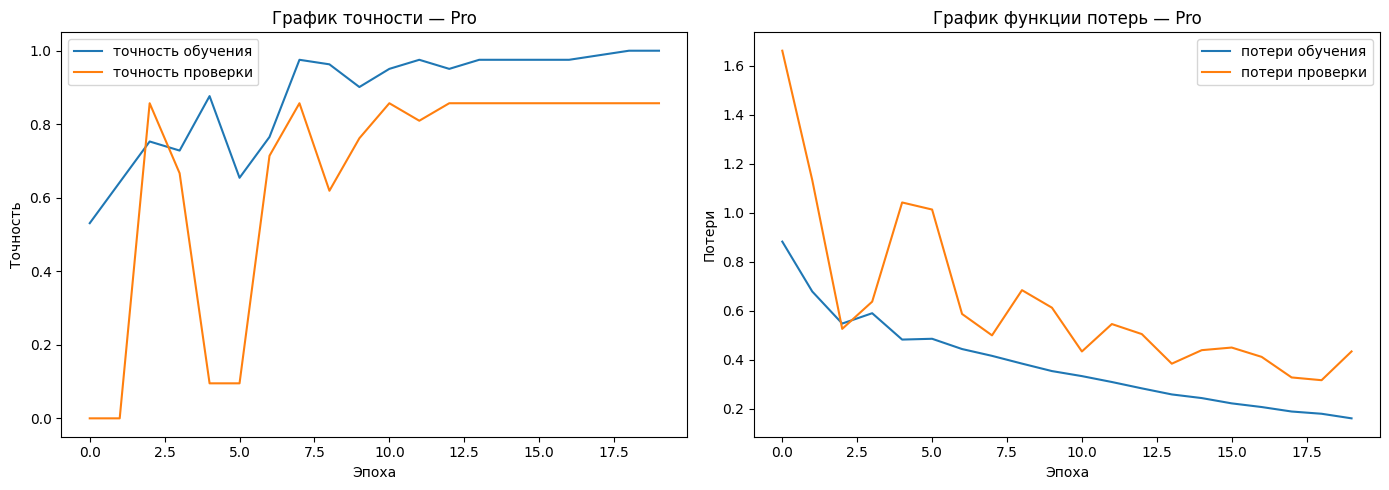

In [10]:
# Графики точности и функции потерь
plot_training_graphs(history, "Pro")


In [11]:
print("Точность обучения:", history.history['accuracy'][-1])
print("Точность проверки:", history.history['val_accuracy'][-1])

Точность обучения: 1.0
Точность проверки: 0.8571428656578064


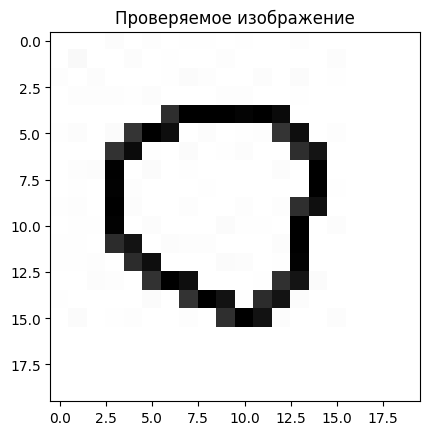

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Нейросеть определила: НОЛИК


In [12]:
# выбираем случайное изображение из обучающей выборки
index = np.random.randint(0, len(x_train))

# показываем изображение
plt.imshow(x_train[index].reshape(20,20), cmap='gray')
plt.title("Проверяемое изображение")
plt.show()

# делаем предсказание
prediction = model.predict(x_train[index].reshape(1,400))

# определяем класс
predicted_class = np.argmax(prediction)

# вывод результата
if predicted_class == 0:
    print("Нейросеть определила: НОЛИК")
else:
    print("Нейросеть определила: КРЕСТИК")